In [2]:
%load_ext rpy2.ipython

### Identify TFs associated with DEGs

In [3]:
%%R

library(enrichR)
library(tidyverse)
library(purrr)

# Define DEG files 
deg_files <- list(
  ko = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_shSIRT6_shCtrl.csv',
  old = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Old_Control.csv',
  s1 = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step1_Control.csv',
  s2 = '/tank/projects/smirnov_rnaseq/kashuk_et_al/sig_genes_pvalue_0_05_Step2_Control.csv'
)

tf_library <- "ChEA_2022"

# Function to process genes and return TF vector
get_tfs <- function(gene_list) {
  if (length(gene_list) == 0) return(character(0))
  
  results <- enrichR::enrichr(genes = gene_list, databases = tf_library)
  res.df <- as.data.frame(results[[1]])
  
  res.df %>% 
    filter(grepl('Mouse', Term), Adjusted.P.value < 0.05) %>%
    mutate(Term = sub(" .*", "", Term)) %>%
    distinct(Term) %>%
    pull(Term)
}

tf_vectors <- list()

for (name in names(deg_files)) {
  df <- read.csv(deg_files[[name]], row.names = 1)
  
  # Downregulated 
  down_genes <- subset(df, log2FoldChange < 0) %>% 
    pull(symbol) %>% 
    toupper()
  tf_vectors[[name]]$down <- get_tfs(down_genes)
  
  # Upregulated 
  up_genes <- subset(df, log2FoldChange > 0) %>% 
    pull(symbol) %>% 
    toupper()
  tf_vectors[[name]]$up <- get_tfs(up_genes)
}


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Uploading data to Enrichr... Done.
  Querying ChEA_2022... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying ChEA_2022... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying ChEA_2022... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying ChEA_2022... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying ChEA_2022... Done.
Parsing results... Done.
Uploading data to Enrichr.

Welcome to enrichR
Checking connection ... 
Enrichr ... Connection is Live!
FlyEnrichr ... Connection is Live!
WormEnrichr ... Connection is Live!
YeastEnrichr ... Connection is Live!
FishEnrichr ... Connection is Live!
OxEnrichr ... Connection is Live!


In [4]:
%%R

tf_vectors

$ko
$ko$down
 [1] "SUZ12"    "REST"     "MTF2"     "MBD3"     "RARB"     "SMARCD1" 
 [7] "RCOR3"    "JARID2"   "CHD4"     "RNF2"     "EZH2"     "ZFP57"   
[13] "YAP1"     "SMARCA4"  "TEAD4"    "MEIS1"    "OLIG2"    "SIN3B"   
[19] "ESR1"     "TAL1"     "BMI1"     "NANOG"    "SOX9"     "TET1"    
[25] "TCFCP2L1" "EED"      "CTCF"     "ZFP281"   "NR3C1"    "CMYC"    
[31] "EBF1"     "ESRRB"    "LMO2"     "KLF4"     "E2F1"     "NR4A2"   
[37] "RING1B"   "P53"      "FOXP2"    "DMRT1"    "FLI1"     "CBX2"    
[43] "RUNX1"    "SMAD3"    "GF1"      "TCF3"     "RCOR1"    "POU5F1"  
[49] "PU1"      "TP53"     "STAT3"    "SOX3"     "ZFP322A"  "NMYC"    
[55] "SMAD1"    "CDX2"     "CEBPD"    "POU3F1"   "ISL1"     "EP300"   
[61] "SOX2"     "OCT4"     "NFE2L2"   "NRF2"     "ZFX"      "WT1"     
[67] "PPARG"    "CRX"      "PHC1"     "KLF5"     "SALL4"    "MYC"     
[73] "GF1B"     "KLF1"     "SETDB1"   "GATA1"    "TBX3"     "CDH4"    
[79] "P300"     "SIN3A"    "MNX1"     "CEBPB"   

$ko$up
  [1] "

### Upload and filter TFs associated with differential chromatin interactions from BART3D

In [5]:
%%R

# Define file paths
bart_files <- c(
  "WT_old_tr_Interaction_Increased_bart3d_results.txt",
  "WT_old_tr_Interaction_Decreased_bart3d_results.txt",
  "WT_KO_tr_Interaction_Increased_bart3d_results.txt",
  "WT_KO_tr_Interaction_Decreased_bart3d_results.txt",
  "control_step1_tr_Interaction_Increased_bart3d_results.txt", 
  "control_step1_tr_Interaction_Decreased_bart3d_results.txt",
  "control_step2_tr_Interaction_Increased_bart3d_results.txt",
  "control_step2_tr_Interaction_Decreased_bart3d_results.txt"
)

base_dir <- "/tank/projects/kashuk_sirt6_hic/tr/bart3d/cool_out2/"

# Process each file
TR_vectors <- list()

for (file in bart_files) {
  # Read and filter data
  df <- read.table(file.path(base_dir, file), header = TRUE)
  df$p.adj <- p.adjust(df$pvalue, method = 'fdr')
  df_filt <- subset(df, p.adj < 0.05)
  
  # Extract TR column
  vec_name <- tools::file_path_sans_ext(file)
  TR_vectors[[vec_name]] <- df_filt$TR
  
  saveRDS(df_filt$TR, file = paste0(vec_name, "_TRvector.rds"))

}

### Intersect TFs assoiated with DEGs and Differential chromatin interactions

#### TFs associated with up-regulated DEGs and increased chromatin interactions

In [6]:
%%R

cases <- list(
  old = "WT_old_tr_Interaction_Increased_bart3d_results_TRvector.rds",
  ko  = "WT_KO_tr_Interaction_Increased_bart3d_results_TRvector.rds",
  s1  = "control_step1_tr_Interaction_Increased_bart3d_results_TRvector.rds",
  s2  = "control_step2_tr_Interaction_Increased_bart3d_results_TRvector.rds"
)


up_lists <- lapply(names(cases), function(name) {
  hic_vec    <- readRDS(cases[[name]])
  rnaseq_vec <- tf_vectors[[name]]$up
  intersect(hic_vec, rnaseq_vec)
})

names(up_lists) <- names(cases)

In [7]:
%%R

up_lists

$old
[1] "SIN3A" "E2F1"  "CREB1" "MYC"   "BRD4" 

$ko
[1] "REST" "TBP"  "TP53" "MYC"  "ISL1" "E2F1"

$s1
[1] "CTCF"  "TP53"  "E2F1"  "MYC"   "CREB1" "BRD4" 

$s2
 [1] "CTCF"  "SIN3A" "TBP"   "GABPA" "RAD21" "ETS1"  "MYC"   "E2F1"  "CREB1"
[10] "BRD4" 



In [8]:
%%R

map <- c(
  ko = "KO_up",
  s1 = "Step1_up",
  s2 = "Step2_up"
)

groups <- setNames(
  up_lists[names(map)],  
  map
)

group_colors <- c(
  KO_up    = 'cornflowerblue',
  Step1_up = 'cyan',
  Step2_up = 'grey'
)

str(groups)

List of 3
 $ KO_up   : chr [1:6] "REST" "TBP" "TP53" "MYC" ...
 $ Step1_up: chr [1:6] "CTCF" "TP53" "E2F1" "MYC" ...
 $ Step2_up: chr [1:10] "CTCF" "SIN3A" "TBP" "GABPA" ...


### Chord diagram 

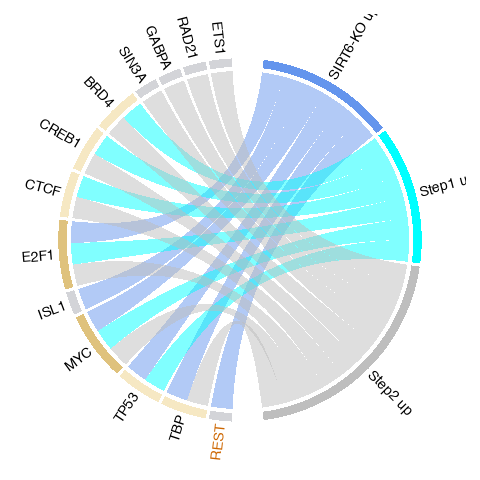

In [11]:
%%R

library(circlize)
library(RColorBrewer)

links <- do.call(rbind, lapply(names(groups), function(group_name) {
  data.frame(from = group_name, to = groups[[group_name]])
}))


# Get unique TFs for sectors
all_tfs <- unique(unlist(groups))

# Define sector order (groups followed by TFs)
sector_order <- c(names(groups), all_tfs)

# Define custom group colors
pal <- brewer.pal(n = 11, name = "BrBG")
tf_link_count <- table(links$to)
tf_colors <- setNames(rep("#D3D4D8", length(all_tfs)), all_tfs)
names(tf_colors) <- names(tf_link_count)

tf_colors[tf_link_count > 1 & tf_link_count <= 2] <- pal[5]  
tf_colors[tf_link_count > 2 & tf_link_count <= 3] <- pal[4] 
tf_colors[tf_link_count > 3] <- pal[3]


# Combine group and TF colors
sector_colors <- c(group_colors, tf_colors)

# Reduce gap degree to fit all sectors
circos.clear()
circos.par(start.degree = 90, gap.degree = 1, cell.padding = c(0.3, 0, 0.02, 0))  # Adjust cell padding

# Initialize the circular plot
circos.initialize(factors = sector_order, xlim = c(0, 1))

chordDiagram(
  links,
  transparency = 0.5,
  grid.col = sector_colors,  
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.1)
)

circos.trackPlotRegion(
  track.index = 1,
  panel.fun = function(x, y) {
    sector.name <- get.cell.meta.data("sector.index")
    xlim <- get.cell.meta.data("xlim")
    ylim <- get.cell.meta.data("ylim")
    

    label <- switch(sector.name,
                    "KO_up" = "SIRT6-KO up",
                    "KO_down" = "SIRT6-KO down",
                    "Old_down" = "Old down",
                    "Step1_up" = "Step1 up",
                    "Step1_down" = "Step1 down",
                    "Step2_up" = "Step2 up",
                    "Step2_down" = "Step2 down",
                    sector.name)  
    
    circos.text(
      mean(xlim), ylim[1], label,
      facing = "clockwise", niceFacing = TRUE,
      adj = c(0, 0.5), cex = 1.13,
      col = ifelse(sector.name == "REST", "darkorange3", "black")  
    )
  },
  bg.border = NA
)

#### TFs associated with down-regulated DEGs and decreased chromatin interactions

In [12]:
%%R

cases <- list(
  old = "WT_old_tr_Interaction_Decreased_bart3d_results_TRvector.rds",
  ko  = "WT_KO_tr_Interaction_Decreased_bart3d_results_TRvector.rds",
  s1  = "control_step1_tr_Interaction_Decreased_bart3d_results_TRvector.rds",
  s2  = "control_step2_tr_Interaction_Decreased_bart3d_results_TRvector.rds"
)


down_lists <- lapply(names(cases), function(name) {
  hic_vec    <- readRDS(cases[[name]])
  rnaseq_vec <- tf_vectors[[name]]$down
  intersect(hic_vec, rnaseq_vec)
})

names(down_lists) <- names(cases)

down_lists

$old
 [1] "CDX2"   "STAT5A" "ISL1"   "NR3C1"  "SOX2"   "MEIS1"  "SOX3"   "POU5F1"
 [9] "NANOG"  "BMI1"   "CEBPB"  "GATA6"  "EP300"  "PPARG"  "GATA2"  "EZH2"  
[17] "TAL1"  

$ko
 [1] "CTCF"   "NR3C1"  "BMI1"   "PPARG"  "LMO2"   "JARID2" "EZH2"   "SUZ12" 
 [9] "ESR1"   "TAL1"   "EBF1"   "RNF2"   "TET1"   "CEBPB" 

$s1
 [1] "ISL1"    "CDX2"    "NR3C1"   "STAT5A"  "MEIS1"   "SOX2"    "EP300"  
 [8] "POU5F1"  "SOX3"    "NANOG"   "CEBPB"   "PPARG"   "TRIM28"  "SMARCA4"
[15] "SALL4"   "OLIG2"   "JUN"     "TEAD4"   "TAL1"    "EZH2"    "IRF8"   
[22] "SPI1"    "RUNX2"   "IRF4"    "SUZ12"  

$s2
 [1] "ISL1"    "MEIS1"   "SOX2"    "POU5F1"  "NANOG"   "CEBPB"   "SMARCA4"
 [8] "OLIG2"   "TEAD4"   "TAL1"   



In [13]:
%%R

map <- c(
  ko = "KO_down",
  old = "Old_down",
  s1 = "Step1_down",
  s2 = "Step2_down"
)

groups <- setNames(
  down_lists[names(map)],  
  map
)

group_colors <- c(
  KO_down = 'cornflowerblue', 
  Old_down = 'deeppink4',
  Step1_down = 'cyan',
  Step2_down = 'grey'
)

str(groups)

List of 4
 $ KO_down   : chr [1:14] "CTCF" "NR3C1" "BMI1" "PPARG" ...
 $ Old_down  : chr [1:17] "CDX2" "STAT5A" "ISL1" "NR3C1" ...
 $ Step1_down: chr [1:25] "ISL1" "CDX2" "NR3C1" "STAT5A" ...
 $ Step2_down: chr [1:10] "ISL1" "MEIS1" "SOX2" "POU5F1" ...


### Chord diagram

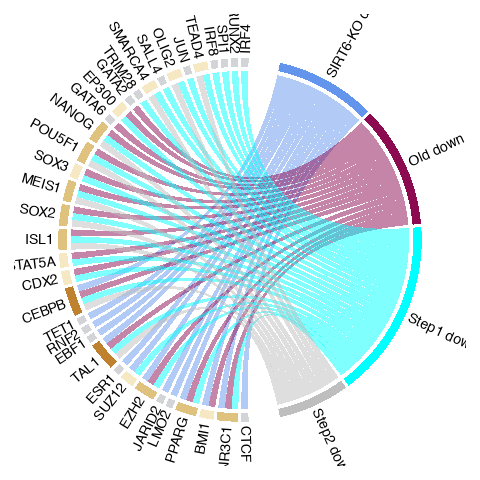

In [14]:
%%R

library(circlize)

links <- do.call(rbind, lapply(names(groups), function(group_name) {
  data.frame(from = group_name, to = groups[[group_name]])
}))


# Get unique TFs for sectors
all_tfs <- unique(unlist(groups))

# Define sector order (groups followed by TFs)
sector_order <- c(names(groups), all_tfs)

# Define custom group colors

tf_link_count <- table(links$to)

tf_colors <- setNames(rep("#D3D4D8", length(all_tfs)), all_tfs)

names(tf_colors) <- names(tf_link_count)

tf_colors[tf_link_count > 1 & tf_link_count <= 2] <- pal[5]  
tf_colors[tf_link_count > 2 & tf_link_count <= 3] <- pal[4] 
tf_colors[tf_link_count > 3] <- pal[3]


# Combine group and TF colors
sector_colors <- c(group_colors, tf_colors)

# Reduce gap degree to fit all sectors
circos.clear()
circos.par(start.degree = 90, gap.degree = 1, cell.padding = c(0.3, 0, 0.02, 0))  # Adjust cell padding

# Initialize the circular plot
circos.initialize(factors = sector_order, xlim = c(0, 1))

chordDiagram(
  links,
  transparency = 0.5,
  grid.col = sector_colors,  
  annotationTrack = "grid",
  preAllocateTracks = list(track.height = 0.1)
)

circos.trackPlotRegion(
  track.index = 1,
  panel.fun = function(x, y) {
    sector.name <- get.cell.meta.data("sector.index")
    xlim <- get.cell.meta.data("xlim")
    ylim <- get.cell.meta.data("ylim")
    

    label <- switch(sector.name,
                    "KO_up" = "SIRT6-KO up",
                    "KO_down" = "SIRT6-KO down",
                    "Old_down" = "Old down",
                    "Step1_up" = "Step1 up",
                    "Step1_down" = "Step1 down",
                    "Step2_up" = "Step2 up",
                    "Step2_down" = "Step2 down",
                    sector.name)  
    
    circos.text(
      mean(xlim), ylim[1], label,
      facing = "clockwise", niceFacing = TRUE,
      adj = c(0, 0.5), cex = 1.13,
      col = ifelse(sector.name == "REST", "darkorange3", "black")  
    )
  },
  bg.border = NA
)

In [15]:
%%R

sessionInfo()

R version 4.4.2 (2024-10-31)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 20.04.6 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/liblapack.so.3;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Moscow
tzcode source: system (glibc)

attached base packages:
[1] tools     stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RColorBrewer_1.1-3 circlize_0.4.16    lubridate_1.9.4    forcats_1.0.0     
 [5] stringr_1.5.1      dplyr_1.1.4        purrr_1.0.2        readr_2.1.5       
 [9] ti